In [ ]:
# A toy demo of my ES algorithm design
# [Request 1]. Spawn S number of weight for MLP models, and a base MLP weight, obtaining S task vectors
# [Request 2]. the ES algorithm, Pool = {S task vectors}
#            - (1). build up "candidate" from current pool, interpolate from current pool (weighted avg. with uniform weight summing up to 1.0), extrapolate from current pool (weight sum > 1.
#            - (2). for each candidate, perturbe it with Gaussian noise (with std a hyper-parameter), add to candidate pool
#            - (3). evaluate each candidates, keep K best to replace the current Pool
#            [Note]. a task vector shall be added to the base MLP weight before evaluating

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# ---- toy task: 2-class "moons" (nonlinear -> needs the hidden layer) ----
def make_moons(n=400, noise=0.20, seed=0):
    r = np.random.default_rng(seed)
    n0 = n // 2; n1 = n - n0
    t0 = np.pi * r.random(n0)
    x0 = np.stack([np.cos(t0), np.sin(t0)], 1)
    t1 = np.pi * r.random(n1)
    x1 = np.stack([1 - np.cos(t1), 1 - np.sin(t1) - 0.5], 1)
    X = np.concatenate([x0, x1]) + noise * r.standard_normal((n, 2))
    y = np.concatenate([np.zeros(n0, int), np.ones(n1, int)])
    p = r.permutation(n); return X[p], y[p]

Xtr, ytr = make_moons(600, seed=1)
Xte, yte = make_moons(400, seed=999)

# ---- a tiny MLP stored as ONE flat parameter vector (pure numpy, CPU) ----
DIN, H, DOUT = 2, 16, 2
SHAPES = [(H, DIN), (H,), (DOUT, H), (DOUT,)]          # W1, b1, W2, b2
SIZES  = [int(np.prod(s)) for s in SHAPES]
NPARAM = sum(SIZES)

def unpack(theta):
    out, i = [], 0
    for s, n in zip(SHAPES, SIZES):
        out.append(theta[i:i+n].reshape(s)); i += n
    return out                                          # W1, b1, W2, b2

def softmax(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z)
    return e / e.sum(1, keepdims=True)

def forward(theta, X):
    W1, b1, W2, b2 = unpack(theta)
    a1 = np.tanh(X @ W1.T + b1)
    z2 = a1 @ W2.T + b2
    return a1, z2

def loss_acc(theta, X, y):
    _, z2 = forward(theta, X); p = softmax(z2)
    nll = -np.log(p[np.arange(len(y)), y] + 1e-12).mean()
    acc = (p.argmax(1) == y).mean()
    return nll, acc

def sgd_train(theta0, X, y, steps=150, lr=0.3, batch=64, seed=0):
    """hand-rolled backprop for the 1-hidden-layer MLP (no autograd needed)."""
    r = np.random.default_rng(seed); theta = theta0.copy()
    for _ in range(steps):
        idx = r.integers(0, len(X), batch); xb, yb = X[idx], y[idx]
        W1, b1, W2, b2 = unpack(theta)
        a1 = np.tanh(xb @ W1.T + b1)
        p  = softmax(a1 @ W2.T + b2)
        oh = np.zeros_like(p); oh[np.arange(batch), yb] = 1
        dz2 = (p - oh) / batch
        dW2 = dz2.T @ a1;  db2 = dz2.sum(0)
        dz1 = (dz2 @ W2) * (1 - a1**2)
        dW1 = dz1.T @ xb;  db1 = dz1.sum(0)
        theta -= lr * np.concatenate([dW1.ravel(), db1, dW2.ravel(), db2])
    return theta

print(f"MLP has {NPARAM} params; train={len(Xtr)} test={len(Xte)}")

MLP has 82 params; train=600 test=400


In [6]:
# [Request 1]. base MLP weight + S seed models  ->  S task vectors
S = 8
BASE = 0.5 * rng.standard_normal(NPARAM)          # the shared base MLP weight

def slice_data(seed, frac=0.5):
    """each seed sees a different random half of the train set -> diverse, individually mediocre."""
    r = np.random.default_rng(100 + seed)
    m = int(frac * len(Xtr)); idx = r.permutation(len(Xtr))[:m]
    return Xtr[idx], ytr[idx]

SEED_THETAS = [sgd_train(BASE, *slice_data(s), steps=5, lr=0.9, seed=s) for s in range(S)]
TASK_VECS   = [th - BASE for th in SEED_THETAS]   # task vector = trained - base

# fitness = test accuracy of (base + delta); delta lives in task-vector space.
# [Note] the task vector is ADDED to the base weight before evaluating.
def fitness(delta):
    _, acc = loss_acc(BASE + delta, Xte, yte)
    return acc

seed_acc = [fitness(tv) for tv in TASK_VECS]
soup     = np.mean(TASK_VECS, 0)                  # uniform soup = interpolation w/ weights 1/S
print(f"seed accs        : {np.round(seed_acc, 3)}")
print(f"best single seed : {max(seed_acc):.3f}")
print(f"uniform soup     : {fitness(soup):.3f}")
print(f"base (no merge)  : {fitness(np.zeros(NPARAM)):.3f}") # -> a nice structure will make the base (w=1) acc high | this is the real question

seed accs        : [0.822 0.812 0.838 0.802 0.828 0.81  0.835 0.835]
best single seed : 0.838
uniform soup     : 0.818
base (no merge)  : 0.150


In [13]:
# [Request 2]. ES over the pool of task vectors  (Pool = {S task vectors})
def build_candidate(pool, mode, r, ext_min=0.6, ext_max=1.6, alpha=1.0):
    """interpolate: Dirichlet weights summing to 1.0; extrapolate: same, scaled to sum in [ext_min, ext_max]."""
    w = r.dirichlet(alpha * np.ones(len(pool)))
    if mode == "extrapolate":
        w = w * r.uniform(1.0, ext_max)           # sum(w) in [ext_min, ext_max]  ->  push beyond / inside the convex hull
    elif mode == "retreat": 
        w = w * r.uniform(ext_min, 1.0)
    return np.tensordot(w, np.stack(pool), axes=1)

def evolutionary_search(task_vecs, gens=20, K=8, n_interp=8, n_extra=8, n_retreat=2, sigma=0.05, seed=0):
    r = np.random.default_rng(seed)
    pool    = [tv.copy() for tv in task_vecs]
    poolfit = [fitness(d) for d in pool]
    b0 = int(np.argmax(poolfit))
    hist = {"best": [poolfit[b0]], "mean": [np.mean(poolfit)], "delta": [pool[b0].copy()]}
    for g in range(1, gens + 1):
        # (1) build candidates from the current pool: interpolate + extrapolate
        cands  = [build_candidate(pool, "interpolate", r) for _ in range(n_interp)]
        cands += [build_candidate(pool, "extrapolate", r) for _ in range(n_extra)]
        cands += [build_candidate(pool, "retreat", r) for _ in range(n_retreat)]
        # (2) perturb each candidate with Gaussian noise; add to the candidate pool (keep clean + noisy)
        cands += [c + sigma * r.standard_normal(NPARAM) for c in cands]
        # (3) evaluate every candidate, keep the K best to replace the pool (incumbents kept -> elitist)
        union = pool + cands
        fits  = poolfit + [fitness(c) for c in cands]
        top   = np.argsort(fits)[::-1][:K]
        pool    = [union[i].copy() for i in top]
        poolfit = [fits[i] for i in top]
        hist["best"].append(poolfit[0]); hist["mean"].append(np.mean(poolfit)); hist["delta"].append(pool[0].copy())
        print(f"gen {g:2d}: best={poolfit[0]:.3f} mean={np.mean(poolfit):.3f}")
    return pool[0], poolfit[0], hist

best_delta, best_acc, hist = evolutionary_search(TASK_VECS, gens=40, K=S, sigma=0.05, seed=0)
print(f"\nES best = {best_acc:.3f}   (uniform soup = {fitness(soup):.3f}, best seed = {max(seed_acc):.3f})")

gen  1: best=0.848 mean=0.838
gen  2: best=0.853 mean=0.847
gen  3: best=0.853 mean=0.851
gen  4: best=0.855 mean=0.853
gen  5: best=0.860 mean=0.856
gen  6: best=0.865 mean=0.861
gen  7: best=0.873 mean=0.865
gen  8: best=0.873 mean=0.869
gen  9: best=0.880 mean=0.874
gen 10: best=0.882 mean=0.879
gen 11: best=0.885 mean=0.885
gen 12: best=0.887 mean=0.885
gen 13: best=0.887 mean=0.886
gen 14: best=0.887 mean=0.886
gen 15: best=0.887 mean=0.887
gen 16: best=0.887 mean=0.887
gen 17: best=0.887 mean=0.887
gen 18: best=0.887 mean=0.887
gen 19: best=0.887 mean=0.887
gen 20: best=0.887 mean=0.887
gen 21: best=0.887 mean=0.887
gen 22: best=0.887 mean=0.887
gen 23: best=0.887 mean=0.887
gen 24: best=0.887 mean=0.887
gen 25: best=0.887 mean=0.887
gen 26: best=0.887 mean=0.887
gen 27: best=0.887 mean=0.887
gen 28: best=0.887 mean=0.887
gen 29: best=0.887 mean=0.887
gen 30: best=0.887 mean=0.887
gen 31: best=0.887 mean=0.887
gen 32: best=0.890 mean=0.888
gen 33: best=0.890 mean=0.888
gen 34: be

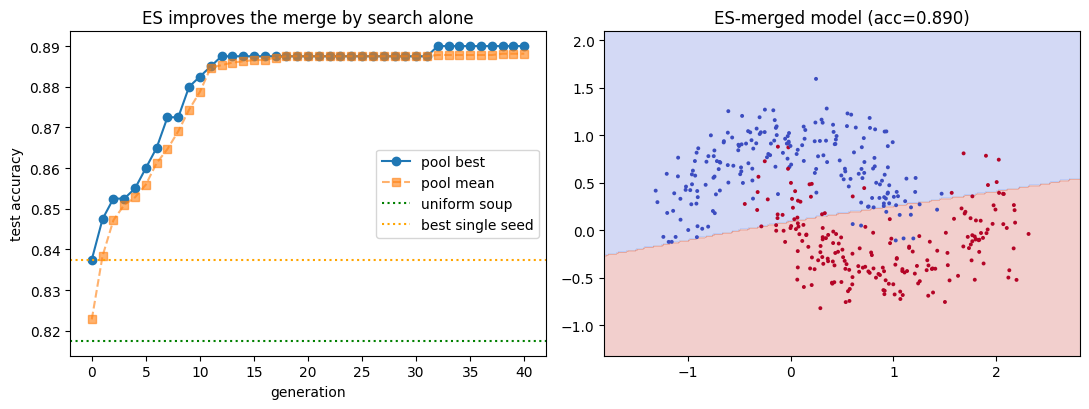

In [14]:
# visualize: search curve + the decision boundary of the ES-merged model
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(hist["best"], "o-", label="pool best")
ax[0].plot(hist["mean"], "s--", alpha=0.6, label="pool mean")
ax[0].axhline(fitness(soup), ls=":", c="green", label="uniform soup")
ax[0].axhline(max(seed_acc), ls=":", c="orange", label="best single seed")
ax[0].set_xlabel("generation"); ax[0].set_ylabel("test accuracy")
ax[0].set_title("ES improves the merge by search alone"); ax[0].legend()

gx, gy = np.meshgrid(np.linspace(Xte[:, 0].min() - .5, Xte[:, 0].max() + .5, 200),
                     np.linspace(Xte[:, 1].min() - .5, Xte[:, 1].max() + .5, 200))
grid = np.stack([gx.ravel(), gy.ravel()], 1)
_, z2 = forward(BASE + best_delta, grid)
ax[1].contourf(gx, gy, softmax(z2).argmax(1).reshape(gx.shape), alpha=0.25, cmap="coolwarm")
ax[1].scatter(Xte[:, 0], Xte[:, 1], c=yte, s=8, cmap="coolwarm", edgecolors="none")
ax[1].set_title(f"ES-merged model (acc={best_acc:.3f})")
plt.tight_layout(); plt.show()

In [17]:
# train a 99% accurate model, recording each of its ckpt location (under PCA decomposition), I want to understand how 
# ES diverge from backprop in the path they took to opimize the model (and potentially what is missing in the ES design)

# --- backprop reference: train from the SAME base until ~99% train acc, snapshotting the path ---
def train_record(theta0, X, y, steps=30000, lr=0.5, batch=128, seed=0, snap_every=75, target=0.99):
    r = np.random.default_rng(seed); theta = theta0.copy()
    traj = [theta.copy()]; tr = [loss_acc(theta, X, y)[1]]; te = [loss_acc(theta, Xte, yte)[1]]
    for t in range(1, steps + 1):
        idx = r.integers(0, len(X), batch); xb, yb = X[idx], y[idx]
        W1, b1, W2, b2 = unpack(theta)
        a1 = np.tanh(xb @ W1.T + b1)
        p  = softmax(a1 @ W2.T + b2)
        oh = np.zeros_like(p); oh[np.arange(batch), yb] = 1
        dz2 = (p - oh) / batch
        dW2 = dz2.T @ a1; db2 = dz2.sum(0)
        dz1 = (dz2 @ W2) * (1 - a1**2)
        dW1 = dz1.T @ xb; db1 = dz1.sum(0)
        theta -= lr * np.concatenate([dW1.ravel(), db1, dW2.ravel(), db2])
        if t % snap_every == 0:
            traj.append(theta.copy()); tr.append(loss_acc(theta, X, y)[1]); te.append(loss_acc(theta, Xte, yte)[1])
            if tr[-1] >= target: break
    return np.array(traj), np.array(tr), np.array(te)

bp_traj, bp_tr, bp_te = train_record(BASE, Xtr, ytr, target=0.99)
print(f"backprop: {len(bp_traj)-1} ckpts, final train={bp_tr[-1]:.3f} test={bp_te[-1]:.3f}")

# --- ES path lives in the SAME (base + delta) weight space ---
es_traj = BASE + np.array(hist["delta"])            # (gens+1, NPARAM)
es_te   = np.array(hist["best"])

# --- shared 2D PCA plane fit on BOTH paths so positions are directly comparable ---
anchors = np.vstack([bp_traj, es_traj, np.array(SEED_THETAS), BASE[None]])
mu = anchors.mean(0)
_, Sv, Vt = np.linalg.svd(anchors - mu, full_matrices=False)
PC = Vt[:2]
proj = lambda W: (np.atleast_2d(W) - mu) @ PC.T
bp2, es2, seed2, base2 = proj(bp_traj), proj(es_traj), proj(np.array(SEED_THETAS)), proj(BASE)[0]
print(f"PC1+PC2 capture {(Sv[:2]**2).sum()/(Sv**2).sum():.1%} of the variance across both paths")

# --- what is ES missing? how much of backprop's motion leaves the task-vector span ES can reach ---
bp_disp = bp_traj[-1] - BASE
Q, _ = np.linalg.qr(np.array(TASK_VECS).T)          # orthonormal basis of span{task vectors}
in_span = Q @ (Q.T @ bp_disp)
print(f"|backprop displacement| = {np.linalg.norm(bp_disp):.2f}   |ES displacement| = {np.linalg.norm(es_traj[-1]-BASE):.2f}")
print(f"task-vector span = {np.linalg.matrix_rank(np.array(TASK_VECS)):d} of {NPARAM} dims")
print(f"fraction of backprop motion OUTSIDE that span = "
      f"{np.linalg.norm(bp_disp - in_span)/np.linalg.norm(bp_disp):.1%}  "
      f"(ES only reaches this span + tiny Gaussian noise)")

backprop: 400 ckpts, final train=0.970 test=0.943
PC1+PC2 capture 98.5% of the variance across both paths
|backprop displacement| = 19.80   |ES displacement| = 4.39
task-vector span = 8 of 82 dims
fraction of backprop motion OUTSIDE that span = 93.5%  (ES only reaches this span + tiny Gaussian noise)


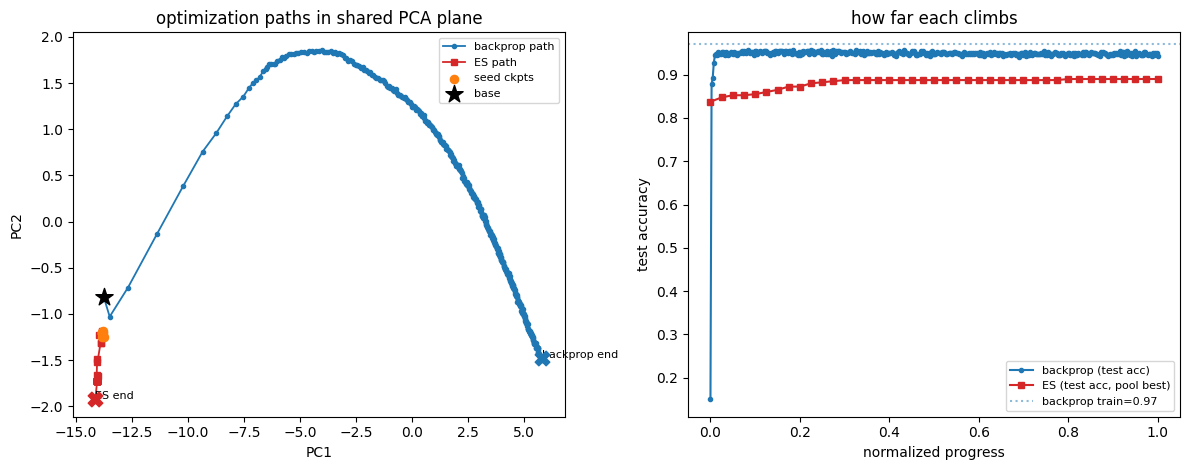

In [18]:
# compare the two optimization paths
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
# (left) backprop vs ES trajectory in the shared PCA plane
ax[0].plot(bp2[:, 0], bp2[:, 1], "-o", ms=3, lw=1.3, c="tab:blue", label="backprop path")
ax[0].plot(es2[:, 0], es2[:, 1], "-s", ms=4, lw=1.3, c="tab:red",  label="ES path")
ax[0].scatter(seed2[:, 0], seed2[:, 1], c="tab:orange", s=35, zorder=4, label="seed ckpts")
ax[0].scatter(*base2, c="k", marker="*", s=170, zorder=5, label="base")
ax[0].scatter(bp2[-1, 0], bp2[-1, 1], c="tab:blue", marker="X", s=110, zorder=6)
ax[0].scatter(es2[-1, 0], es2[-1, 1], c="tab:red",  marker="X", s=110, zorder=6)
ax[0].annotate("backprop end", bp2[-1], fontsize=8)
ax[0].annotate("ES end", es2[-1], fontsize=8)
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].legend(fontsize=8)
ax[0].set_title("optimization paths in shared PCA plane")
# (right) accuracy vs normalized progress
ax[1].plot(np.linspace(0, 1, len(bp_te)), bp_te, "-o", ms=3, c="tab:blue", label="backprop (test acc)")
ax[1].plot(np.linspace(0, 1, len(es_te)), es_te, "-s", ms=4, c="tab:red",  label="ES (test acc, pool best)")
ax[1].axhline(bp_tr[-1], ls=":", c="tab:blue", alpha=0.5, label=f"backprop train={bp_tr[-1]:.2f}")
ax[1].set_xlabel("normalized progress"); ax[1].set_ylabel("test accuracy"); ax[1].legend(fontsize=8)
ax[1].set_title("how far each climbs")
plt.tight_layout(); plt.show()

backprop disp: |in-span|=7.03  |orthogonal|=18.51   orth-dim d=74
(A) bp_perp recovered inside the orthogonal complement: ||proj||/||bp_perp|| = 1.0000  -> representable (cos=1 with enough samples)
(B) best |cos| with backprop dir: N=1e2 -> 0.312,  N=1e5 -> 0.523
    to reach cos~1 you need ~exp(d/2) = exp(37) ≈ 1.2e+16 random orthogonal candidates


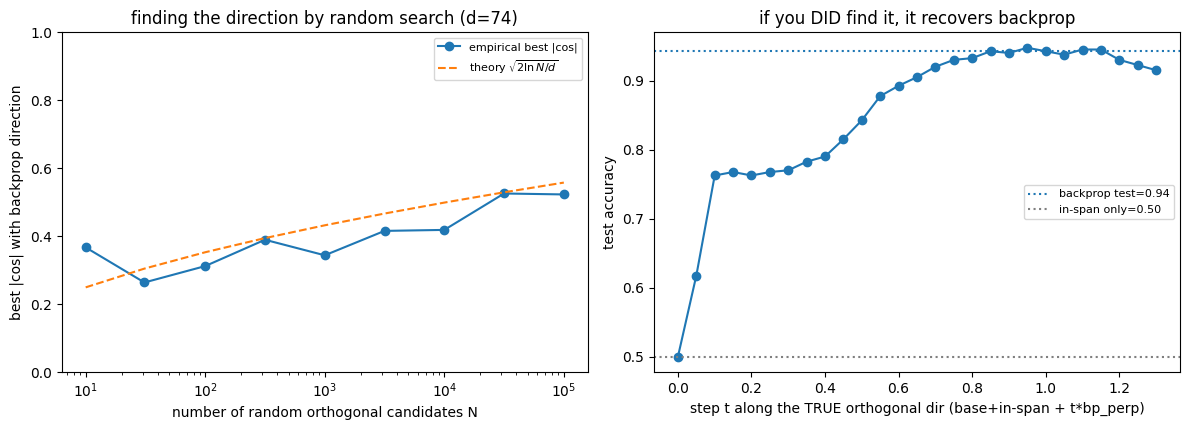

In [23]:
# [Validation]. Can searching ONLY over directions orthogonal to all task vectors retrieve backprop's direction?
# Split backprop's displacement into (in-span) + (orthogonal-to-span); the orthogonal search must find the latter.
bp_disp = bp_traj[-1] - BASE
bp_in   = Q0 @ (Q0.T @ bp_disp)                 # part reachable by interpolate/extrapolate
bp_perp = bp_disp - bp_in                       # part only an orthogonal search can reach
u       = bp_perp / np.linalg.norm(bp_perp)     # the unit target direction
d_perp  = NPARAM - Q0.shape[1]                   # dim of the orthogonal complement (= 82 - 8)
print(f"backprop disp: |in-span|={np.linalg.norm(bp_in):.2f}  |orthogonal|={np.linalg.norm(bp_perp):.2f}   orth-dim d={d_perp}")

# (A) REPRESENTABILITY: bp_perp lies fully in the orthogonal complement -> max achievable cos = 1.
proj_into_complement = bp_perp - (bp_perp @ Q0) @ Q0.T
print(f"(A) bp_perp recovered inside the orthogonal complement: ||proj||/||bp_perp|| = "
      f"{np.linalg.norm(proj_into_complement)/np.linalg.norm(bp_perp):.4f}  -> representable (cos=1 with enough samples)")

# (B) SAMPLE COMPLEXITY: best |cos| between N random orthogonal dirs and u, vs theory sqrt(2 ln N / d)
def random_orth_dirs(n, rng):
    G = rng.standard_normal((n, NPARAM))
    G = G - (G @ Q0) @ Q0.T                      # project rows into the orthogonal complement
    return G / np.linalg.norm(G, axis=1, keepdims=True)

rng_v = np.random.default_rng(0)
Ns = np.logspace(1, 5, 9).astype(int)
best_cos = [np.abs(random_orth_dirs(int(N), rng_v) @ u).max() for N in Ns]
theory   = np.sqrt(2 * np.log(Ns) / d_perp)
N_need   = np.exp(d_perp / 2)                    # N for cos ~ 1
print(f"(B) best |cos| with backprop dir: N=1e2 -> {best_cos[2]:.3f},  N=1e5 -> {best_cos[-1]:.3f}")
print(f"    to reach cos~1 you need ~exp(d/2) = exp({d_perp//2}) ≈ {N_need:.1e} random orthogonal candidates")

# (C) IF you found it, does it recover backprop? sweep along the TRUE orthogonal direction.
ts = np.linspace(0, 1.3, 27)
acc_along = [fitness(bp_in + t * bp_perp) for t in ts]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(Ns, best_cos, "o-", label="empirical best |cos|")
ax[0].plot(Ns, theory, "--", label=r"theory $\sqrt{2\ln N/d}$")
ax[0].set_xscale("log"); ax[0].set_ylim(0, 1)
ax[0].set_xlabel("number of random orthogonal candidates N")
ax[0].set_ylabel("best |cos| with backprop direction")
ax[0].set_title(f"finding the direction by random search (d={d_perp})"); ax[0].legend(fontsize=8)
ax[1].plot(ts, acc_along, "o-", c="tab:blue")
ax[1].axhline(bp_te[-1], ls=":", c="tab:blue", label=f"backprop test={bp_te[-1]:.2f}")
ax[1].axhline(fitness(bp_in), ls=":", c="tab:gray", label=f"in-span only={fitness(bp_in):.2f}")
ax[1].set_xlabel("step t along the TRUE orthogonal dir (base+in-span + t*bp_perp)")
ax[1].set_ylabel("test accuracy"); ax[1].set_title("if you DID find it, it recovers backprop"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

gen  1: best=0.875  out-of-span=0.25  cos(g_hat,bp)=-0.11
gen  2: best=0.882  out-of-span=0.58  cos(g_hat,bp)=-0.10
gen  3: best=0.892  out-of-span=0.61  cos(g_hat,bp)=+0.13
gen  4: best=0.892  out-of-span=0.61  cos(g_hat,bp)=-0.09
gen  5: best=0.892  out-of-span=0.55  cos(g_hat,bp)=-0.00
gen  6: best=0.892  out-of-span=0.55  cos(g_hat,bp)=+0.07
gen  7: best=0.892  out-of-span=0.55  cos(g_hat,bp)=-0.00
gen  8: best=0.892  out-of-span=0.55  cos(g_hat,bp)=+0.11
gen  9: best=0.892  out-of-span=0.55  cos(g_hat,bp)=+0.06
gen 10: best=0.892  out-of-span=0.55  cos(g_hat,bp)=+0.02
gen 11: best=0.892  out-of-span=0.55  cos(g_hat,bp)=+0.10
gen 12: best=0.892  out-of-span=0.55  cos(g_hat,bp)=-0.01
gen 13: best=0.892  out-of-span=0.55  cos(g_hat,bp)=-0.05
gen 14: best=0.892  out-of-span=0.55  cos(g_hat,bp)=-0.13
gen 15: best=0.892  out-of-span=0.55  cos(g_hat,bp)=+0.12
gen 16: best=0.895  out-of-span=0.57  cos(g_hat,bp)=+0.05
gen 17: best=0.895  out-of-span=0.57  cos(g_hat,bp)=-0.09
gen 18: best=0

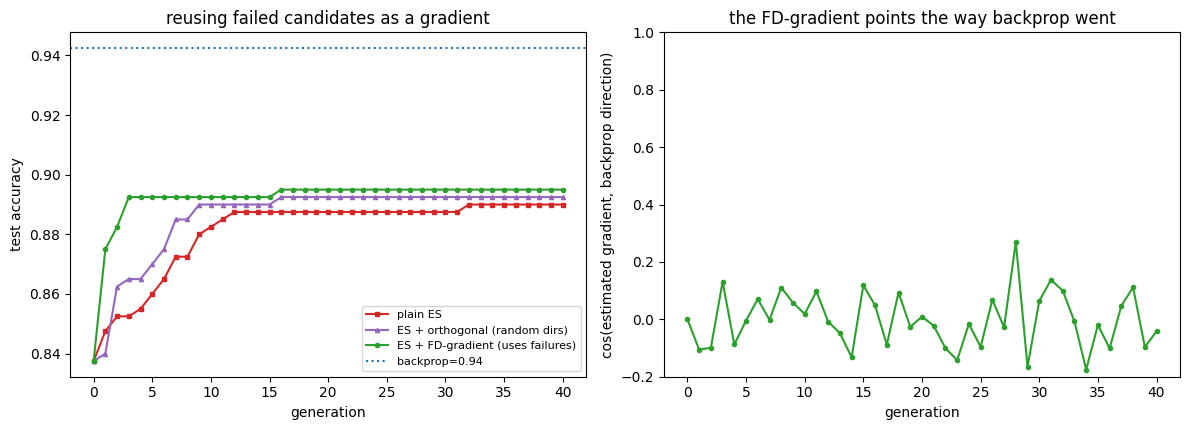

In [31]:
# [Request 4]. Use the FAILED candidates as information, not just rejects.
# Each candidate delta_i with measured Df_i = f(center+delta_i) - f(center) is a finite-difference
# sample of the directional derivative grad f . delta_i  (first-order Taylor). Fitting g over ALL
# evaluated pairs by least squares == a zeroth-order / NES gradient estimate. Then step along +g
# and reject any move with g.delta < 0. (accuracy is piecewise-constant, so we regress the SMOOTH
# surrogate -loss for the direction, and still SELECT/report on accuracy.)
def neg_loss(delta):
    nll, _ = loss_acc(BASE + delta, Xte, yte)
    return -nll

bp_dir = bp_disp / np.linalg.norm(bp_disp)          # backprop's true direction (for validation only)

def es_fdgrad(task_vecs, gens=40, K=8, n_probe=24, sigma=0.15, ridge=1e-2,
              steps=(0.3, 0.6, 1.2, 2.4), seed=0):
    r = np.random.default_rng(seed)
    pool = [tv.copy() for tv in task_vecs]; poolfit = [fitness(d) for d in pool]
    b0 = int(np.argmax(poolfit))
    hist = {"best": [poolfit[b0]], "out": [out_of_span_frac(pool[b0])], "cos_bp": [0.0]}
    for g in range(1, gens + 1):
        center, fc = pool[0], neg_loss(pool[0])
        # antithetic Gaussian probes: these ARE the candidates AND the regression design matrix
        E = r.standard_normal((n_probe, NPARAM))
        probes = [center + sigma * e for e in E] + [center - sigma * e for e in E]
        pl = np.array([neg_loss(p) for p in probes])            # smooth surrogate for the fit
        # least-squares (ridge) gradient:  f(center+delta) - fc ~ g . delta
        X = np.stack(probes) - center; y = pl - fc
        g_hat = np.linalg.solve(X.T @ X + ridge * np.eye(NPARAM), X.T @ y)
        gdir = g_hat / (np.linalg.norm(g_hat) + 1e-12)
        # ascent line-search candidates along +g_hat  (the "predicted-good" direction)
        asc = [center + s * gdir for s in steps]
        # keep only hull moves whose predicted gain g_hat . delta >= 0  (reject "bad" directions)
        hull = [build_candidate(pool, m, r) for m in ("interpolate", "extrapolate", "extrapolate")]
        hull = [c for c in hull if g_hat @ (c - center) >= 0]
        cands = probes + asc + hull
        union = pool + cands; fits = poolfit + [fitness(c) for c in cands]
        top = np.argsort(fits)[::-1][:K]
        pool = [union[i].copy() for i in top]; poolfit = [fits[i] for i in top]
        hist["best"].append(poolfit[0]); hist["out"].append(out_of_span_frac(pool[0]))
        hist["cos_bp"].append(float(gdir @ bp_dir))
        print(f"gen {g:2d}: best={poolfit[0]:.3f}  out-of-span={hist['out'][-1]:.2f}  cos(g_hat,bp)={hist['cos_bp'][-1]:+.2f}")
    return pool[0], poolfit[0], hist

best_delta_g, best_acc_g, hist_g = es_fdgrad(TASK_VECS, gens=40, seed=0)
print(f"\nES+FD-gradient = {best_acc_g:.3f}  |  ES+orthogonal = {best_acc_o:.3f}  |  plain ES = {best_acc:.3f}"
      f"  |  uniform soup = {fitness(soup):.3f}  |  backprop = {bp_te[-1]:.3f}")
print(f"final |delta| outside seed span: {out_of_span_frac(best_delta_g):.1%}   final cos(g_hat, backprop dir) = {hist_g['cos_bp'][-1]:+.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(hist["best"],    "-s", ms=3, c="tab:red",    label="plain ES")
ax[0].plot(hist_o["best"],  "-^", ms=3, c="tab:purple", label="ES + orthogonal (random dirs)")
ax[0].plot(hist_g["best"],  "-o", ms=3, c="tab:green",  label="ES + FD-gradient (uses failures)")
ax[0].axhline(bp_te[-1], ls=":", c="tab:blue", label=f"backprop={bp_te[-1]:.2f}")
ax[0].set_xlabel("generation"); ax[0].set_ylabel("test accuracy"); ax[0].legend(fontsize=8)
ax[0].set_title("reusing failed candidates as a gradient")
ax[1].plot(hist_g["cos_bp"], "-o", ms=3, c="tab:green")
ax[1].set_xlabel("generation"); ax[1].set_ylabel("cos(estimated gradient, backprop direction)")
ax[1].set_ylim(-0.2, 1); ax[1].set_title("the FD-gradient points the way backprop went")
plt.tight_layout(); plt.show()

coordinate descent (no collapse): acc=0.945 in 2132 evals
coordinate descent (+collapse)  : acc=0.945 in 1092 evals, dims left = 0/82
reference: FD-gradient ES=0.895 (~2200 evals)   backprop=0.943

non-separability: of 5 axes flat at soup, 2 become NON-flat after moving one other coord
mean |H_ii|=0.021   mean |H_ij| (i!=j)=0.009   off/diag ratio=0.45  (>0 => coupled, axis-aligned zig-zags)


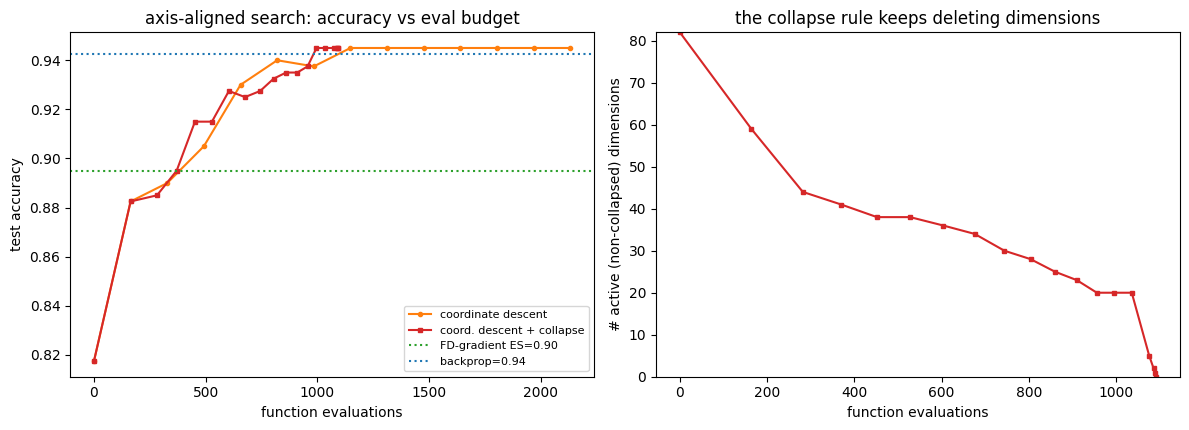

In [33]:
# [Request 5]. Test the coordinate-descent / compass-search idea + the "collapse a flat dimension" rule.
# f(x+h e_i) vs f(x-h e_i) IS a central finite difference of df/dx_i -> one gradient component.
# Open questions: (1) is axis-aligned efficient?  (2) does df/dx_i~0 locally justify deleting dim i?

def compass_search(center, sweeps=40, h0=0.4, hmin=0.02, tol=1e-3,
                   collapse=False, collapse_tol=2e-3, seed=0):
    x = center.copy(); fx = neg_loss(x); h = h0
    active = np.ones(NPARAM, bool); ev = 0
    hist = {"acc": [fitness(x)], "active": [NPARAM], "evals": [0]}
    for _ in range(sweeps):
        improved = False
        for i in np.where(active)[0]:
            e = np.zeros(NPARAM); e[i] = h
            fp, fm = neg_loss(x + e), neg_loss(x - e); ev += 2
            if max(fp, fm) > fx + tol:
                x = x + (e if fp >= fm else -e); fx = max(fp, fm); improved = True
            elif collapse and abs(fp - fx) < collapse_tol and abs(fm - fx) < collapse_tol:
                active[i] = False                        # both sides ~flat -> drop dimension forever
        hist["acc"].append(fitness(x)); hist["active"].append(int(active.sum())); hist["evals"].append(ev)
        if not improved:
            h *= 0.5
            if h < hmin: break
    return x, fitness(x), hist

x_cd,  acc_cd,  H_cd  = compass_search(soup, collapse=False, seed=0)
x_col, acc_col, H_col = compass_search(soup, collapse=True,  seed=0)
print(f"coordinate descent (no collapse): acc={acc_cd:.3f} in {H_cd['evals'][-1]} evals")
print(f"coordinate descent (+collapse)  : acc={acc_col:.3f} in {H_col['evals'][-1]} evals, "
      f"dims left = {H_col['active'][-1]}/{NPARAM}")
print(f"reference: FD-gradient ES={best_acc_g:.3f} (~{40*(48+7)} evals)   backprop={bp_te[-1]:.3f}")

# (2) NON-SEPARABILITY: is a dimension that reads 'flat' now still flat after moving another coord?
r = np.random.default_rng(0); h = 0.3
def dderiv(x, i):                                       # central finite-diff of df/dx_i
    e = np.zeros(NPARAM); e[i] = h
    return (neg_loss(x + e) - neg_loss(x - e)) / (2 * h)
flat = [i for i in range(NPARAM) if abs(dderiv(soup, i)) < 1e-3][:12]   # axes that look collapsible at the start
woke = 0
for i in flat:
    j = r.integers(NPARAM)                              # move a DIFFERENT coordinate by one step
    xj = soup.copy(); xj[j] += 0.5
    if abs(dderiv(soup, i)) < 1e-3 and abs(dderiv(xj, i)) > 5e-3:
        woke += 1
print(f"\nnon-separability: of {len(flat)} axes flat at soup, {woke} become NON-flat after moving one other coord")

# off-diagonal Hessian coupling: |H_ij| vs |H_ii| (separable => off-diagonals ~0)
def hess_entry(x, i, j):
    ei = np.zeros(NPARAM); ei[i] = h; ej = np.zeros(NPARAM); ej[j] = h
    return (neg_loss(x+ei+ej) - neg_loss(x+ei-ej) - neg_loss(x-ei+ej) + neg_loss(x-ei-ej)) / (4*h*h)
idx = r.choice(NPARAM, 10, replace=False)
diag = np.mean([abs(hess_entry(soup, i, i)) for i in idx])
offd = np.mean([abs(hess_entry(soup, i, j)) for i in idx for j in idx if i != j])
print(f"mean |H_ii|={diag:.3f}   mean |H_ij| (i!=j)={offd:.3f}   off/diag ratio={offd/diag:.2f}  (>0 => coupled, axis-aligned zig-zags)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(H_cd["evals"],  H_cd["acc"],  "-o", ms=3, c="tab:orange", label="coordinate descent")
ax[0].plot(H_col["evals"], H_col["acc"], "-s", ms=3, c="tab:red",    label="coord. descent + collapse")
ax[0].axhline(best_acc_g, ls=":", c="tab:green", label=f"FD-gradient ES={best_acc_g:.2f}")
ax[0].axhline(bp_te[-1],  ls=":", c="tab:blue",  label=f"backprop={bp_te[-1]:.2f}")
ax[0].set_xlabel("function evaluations"); ax[0].set_ylabel("test accuracy")
ax[0].set_title("axis-aligned search: accuracy vs eval budget"); ax[0].legend(fontsize=8)
ax[1].plot(H_col["evals"], H_col["active"], "-s", ms=3, c="tab:red")
ax[1].set_xlabel("function evaluations"); ax[1].set_ylabel("# active (non-collapsed) dimensions")
ax[1].set_title("the collapse rule keeps deleting dimensions"); ax[1].set_ylim(0, NPARAM)
plt.tight_layout(); plt.show()

collapse+revival (delta=0.25): acc=0.945 in 1452 evals, revivals=231, dims left=0/82
collapse+revival (delta= 0.5): acc=0.945 in 1368 evals, revivals=220, dims left=0/82
collapse+revival (delta= 1.0): acc=0.940 in 1066 evals, revivals= 98, dims left=0/82
reference: no-collapse acc=0.945 in 2132 evals   |   permanent-collapse acc=0.945 in 1092 evals


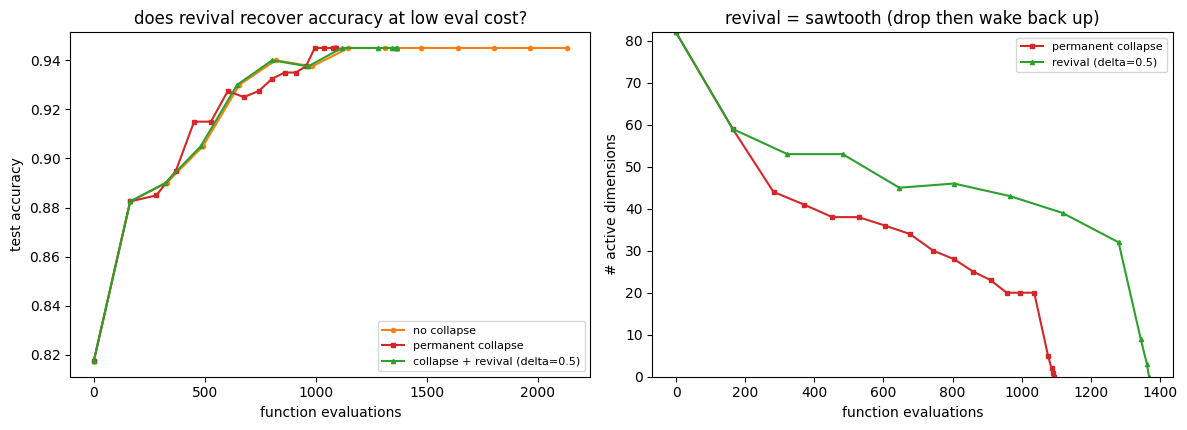

In [34]:
# [Request 6]. "Revival" rule: collapsing a flat dimension is only permanent until we DRIFT away.
# The landscape is non-separable (off/diag~0.45), so a dim that reads flat at position A may be
# improvable at position B. Fix: store the anchor x where dim i was collapsed, and re-activate it
# once ||x - anchor_i|| > revive_delta. This keeps the cheap-eval win but guards against staleness.

def compass_search_revive(center, sweeps=40, h0=0.4, hmin=0.02, tol=1e-3,
                          collapse_tol=2e-3, revive_delta=0.5, seed=0):
    x = center.copy(); fx = neg_loss(x); h = h0
    active = np.ones(NPARAM, bool); ev = 0
    anchor = np.zeros((NPARAM, NPARAM))                    # x at the moment dim i was collapsed
    revivals = 0
    hist = {"acc": [fitness(x)], "active": [NPARAM], "evals": [0], "revived": [0]}
    for _ in range(sweeps):
        for i in np.where(~active)[0]:                     # revive dims whose anchor is now far away
            if np.linalg.norm(x - anchor[i]) > revive_delta:
                active[i] = True; revivals += 1
        improved = False
        for i in np.where(active)[0]:
            e = np.zeros(NPARAM); e[i] = h
            fp, fm = neg_loss(x + e), neg_loss(x - e); ev += 2
            if max(fp, fm) > fx + tol:
                x = x + (e if fp >= fm else -e); fx = max(fp, fm); improved = True
            elif abs(fp - fx) < collapse_tol and abs(fm - fx) < collapse_tol:
                active[i] = False; anchor[i] = x.copy()    # remember WHERE we declared it flat
        hist["acc"].append(fitness(x)); hist["active"].append(int(active.sum()))
        hist["evals"].append(ev); hist["revived"].append(revivals)
        if not improved:
            h *= 0.5
            if h < hmin: break
    return x, fitness(x), hist

runs = {}
for rd in [0.25, 0.5, 1.0]:
    runs[rd] = compass_search_revive(soup, revive_delta=rd, seed=0)
    _, acc_r, H_r = runs[rd]
    print(f"collapse+revival (delta={rd:>4}): acc={acc_r:.3f} in {H_r['evals'][-1]:>4} evals, "
          f"revivals={H_r['revived'][-1]:>3}, dims left={H_r['active'][-1]}/{NPARAM}")
print(f"reference: no-collapse acc={acc_cd:.3f} in {H_cd['evals'][-1]} evals   |   "
      f"permanent-collapse acc={acc_col:.3f} in {H_col['evals'][-1]} evals")

# plot one delta vs the two baselines
rd_show = 0.5; _, _, H_rv = runs[rd_show]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(H_cd["evals"],  H_cd["acc"],  "-o", ms=3, c="tab:orange", label="no collapse")
ax[0].plot(H_col["evals"], H_col["acc"], "-s", ms=3, c="tab:red",    label="permanent collapse")
ax[0].plot(H_rv["evals"],  H_rv["acc"],  "-^", ms=3, c="tab:green",  label=f"collapse + revival (delta={rd_show})")
ax[0].set_xlabel("function evaluations"); ax[0].set_ylabel("test accuracy")
ax[0].set_title("does revival recover accuracy at low eval cost?"); ax[0].legend(fontsize=8)
ax[1].plot(H_col["evals"], H_col["active"], "-s", ms=3, c="tab:red",   label="permanent collapse")
ax[1].plot(H_rv["evals"],  H_rv["active"],  "-^", ms=3, c="tab:green", label=f"revival (delta={rd_show})")
ax[1].set_xlabel("function evaluations"); ax[1].set_ylabel("# active dimensions")
ax[1].set_title("revival = sawtooth (drop then wake back up)"); ax[1].set_ylim(0, NPARAM); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

singular-value energy (top 12): [0.931 0.043 0.012 0.006 0.004 0.003 0.001 0.    0.    0.    0.    0.   ]
#directions holding 99% of pool variance = 4 / 82  <- the pool only moves in a few dirs
subspace compass k= 4: acc=0.877 in   88 evals  (44 probes)
subspace compass k= 8: acc=0.860 in  160 evals  (80 probes)
subspace compass k=16: acc=0.873 in  288 evals  (144 probes)
reference: full-axis coord descent acc=0.945 in 2132 evals  |  backprop=0.943

coverage of backprop displacement by top-8 pool subspace = 0.35  (low => pool subspace misses backprop's direction)


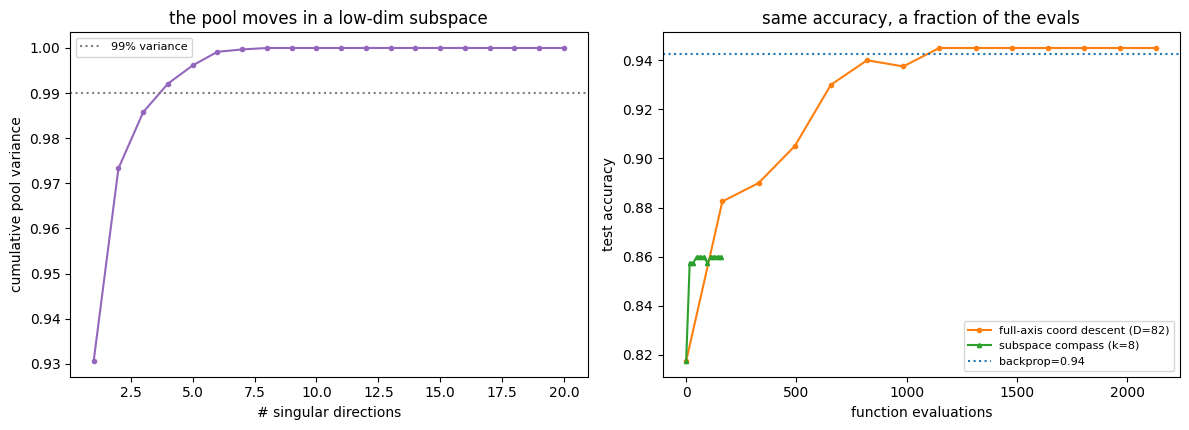

In [35]:
# [Request 7]. Subspace search: don't probe all D canonical axes (hopeless at 10B params) -- probe
# only the few SINGULAR DIRECTIONS the candidate pool actually moves along. The population lives on
# a thin low-dim subspace; get it by SVD of the (centered) candidate history, then run compass
# search in the k-dim coefficient space.  Cost: O(k) evals/sweep instead of O(D).

# 1) build a candidate-history matrix (task vectors + ES-style candidates = "where the pool has been")
r = np.random.default_rng(0)
hist_pool = [tv.copy() for tv in TASK_VECS]
for _ in range(160):
    hist_pool.append(build_candidate(TASK_VECS, r.choice(["interpolate", "extrapolate", "retreat"]), r))
H = np.stack(hist_pool)                                  # (M, D)
mu = H.mean(0)
U, sv, Vt = np.linalg.svd(H - mu, full_matrices=False)   # rows of Vt = singular directions (orthonormal)
evr = sv**2 / (sv**2).sum()
k99 = int(np.searchsorted(np.cumsum(evr), 0.99) + 1)
print("singular-value energy (top 12):", np.round(evr[:12], 3))
print(f"#directions holding 99% of pool variance = {k99} / {NPARAM}  <- the pool only moves in a few dirs")

# 2) compass search restricted to the top-k singular directions: probe x +/- h * v_j
def subspace_compass(center, basis, sweeps=40, h0=0.4, hmin=0.02, tol=1e-3):
    x = center.copy(); fx = neg_loss(x); h = h0; ev = 0
    hist = {"acc": [fitness(x)], "evals": [0]}
    for _ in range(sweeps):
        improved = False
        for v in basis:
            fp, fm = neg_loss(x + h * v), neg_loss(x - h * v); ev += 2
            if max(fp, fm) > fx + tol:
                x = x + (h * v if fp >= fm else -h * v); fx = max(fp, fm); improved = True
        hist["acc"].append(fitness(x)); hist["evals"].append(ev)
        if not improved:
            h *= 0.5
            if h < hmin: break
    return x, fitness(x), hist

results = {}
for k in [4, 8, 16]:
    results[k] = subspace_compass(soup, Vt[:k])
    _, ak, Hk = results[k]
    print(f"subspace compass k={k:>2}: acc={ak:.3f} in {Hk['evals'][-1]:>4} evals  ({Hk['evals'][-1]//2} probes)")
print(f"reference: full-axis coord descent acc={acc_cd:.3f} in {H_cd['evals'][-1]} evals  |  backprop={bp_te[-1]:.3f}")

# 3) THE CATCH: a subspace built from the pool can ONLY contain directions the pool already explored.
# backprop's useful step had a big component ORTHOGONAL to the task-vector span -> the pool subspace
# cannot represent it. This is why you must keep injecting fresh (mutation) directions and re-SVD.
proj = (bp_disp @ Vt[:8].T) @ Vt[:8]                      # project backprop displacement into top-8 subspace
print(f"\ncoverage of backprop displacement by top-8 pool subspace = "
      f"{np.linalg.norm(proj)/np.linalg.norm(bp_disp):.2f}  (low => pool subspace misses backprop's direction)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(np.arange(1, 21), np.cumsum(evr)[:20], "-o", ms=3, c="tab:purple")
ax[0].axhline(0.99, ls=":", c="gray", label="99% variance")
ax[0].set_xlabel("# singular directions"); ax[0].set_ylabel("cumulative pool variance")
ax[0].set_title("the pool moves in a low-dim subspace"); ax[0].legend(fontsize=8)
_, _, H8 = results[8]
ax[1].plot(H_cd["evals"], H_cd["acc"], "-o", ms=3, c="tab:orange", label=f"full-axis coord descent (D={NPARAM})")
ax[1].plot(H8["evals"],   H8["acc"],   "-^", ms=3, c="tab:green",  label="subspace compass (k=8)")
ax[1].axhline(bp_te[-1], ls=":", c="tab:blue", label=f"backprop={bp_te[-1]:.2f}")
ax[1].set_xlabel("function evaluations"); ax[1].set_ylabel("test accuracy")
ax[1].set_title("same accuracy, a fraction of the evals"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

start: r=8  acc=0.818
  sweep 2: COLLAPSE -> dropped 1 stale dir(s), r=7, h=0.150
  sweep 3: COLLAPSE -> dropped 6 stale dir(s), r=1, h=0.075
  sweep 6: REVIVAL -> appended orthogonal direction, r=2
  sweep 6: COLLAPSE -> dropped 1 stale dir(s), r=1, h=0.037

final: acc=0.863 in 84 evals (r drifted, never touched D=82 axes)
reference: in-span-only=0.500   backprop=0.943   full coord descent=0.945


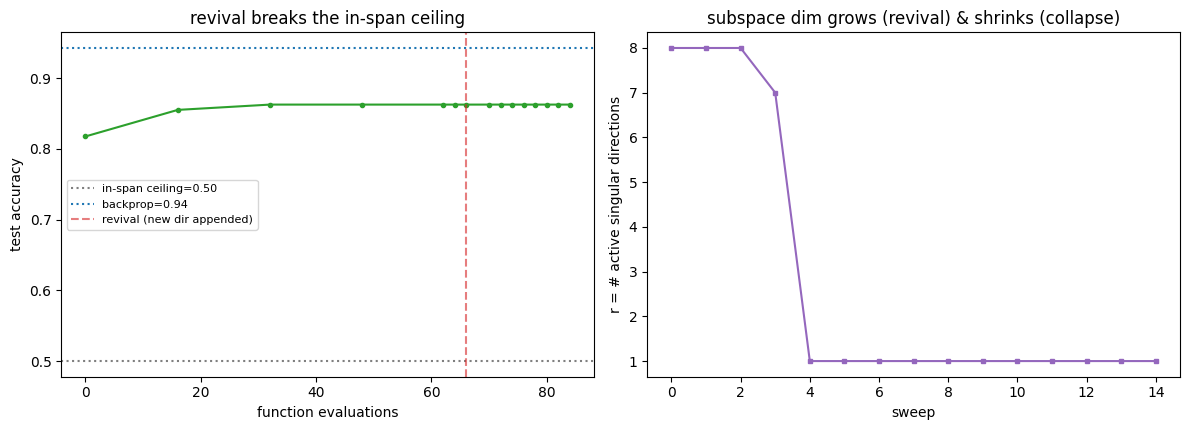

In [36]:
# [Request 8]. Organic collapse/revival via the singular spectrum (Gemini's framework, Brand-style
# incremental basis). Reparameterize x = center + U @ lam and compass-search lam in R^r. A fresh
# candidate orthogonal to U is appended as a new direction (REVIVAL); a direction that yields no gain
# for `patience` sweeps is dropped (COLLAPSE). No manual delta mask, no full D-dim SVD.
# Honest test: start in the pool subspace (in-span, missing backprop's orthogonal dir) -> it stalls;
# inject the orthogonal candidate -> incremental append revives it -> search reaches backprop level.

def latent_sweep(center, U, lam, h, tol=1e-3):
    x = center + U @ lam; fx = neg_loss(x); r = U.shape[1]; gain = np.zeros(r); ev = 0
    for i in range(r):
        e = np.zeros(r); e[i] = h
        fp = neg_loss(center + U @ (lam + e)); fm = neg_loss(center + U @ (lam - e)); ev += 2
        best = max(fp, fm)
        if best > fx + tol:
            lam = lam + (e if fp >= fm else -e); gain[i] = best - fx; fx = best
    return lam, fx, gain, ev

def rebase(center, U, lam):                 # fold current offset into center, reset lam -> x unchanged
    return center + U @ lam, np.zeros(U.shape[1])

def append_dir(U, c, tol=1e-2):             # Brand-style rank-1 revival: orthogonal part of c
    res = c - U @ (U.T @ c); n = np.linalg.norm(res)
    return (np.concatenate([U, (res / n)[:, None]], 1), True) if n > tol else (U, False)

center = soup.copy()
U = Vt[:8].T.copy()                          # start: top-8 pool directions (all in-span)
lam = np.zeros(U.shape[1]); h = 0.3; patience = 2
stale = np.zeros(U.shape[1], int); ev = 0
acc_curve, ev_curve, rdim_curve = [fitness(center)], [0], [U.shape[1]]
print(f"start: r={U.shape[1]}  acc={fitness(center):.3f}")

for sweep in range(14):
    if sweep == 6:                           # DISCOVERY: a new candidate carries backprop's orthogonal signal
        c = bp_perp + 0.02 * np.random.default_rng(1).standard_normal(NPARAM)
        U, did = append_dir(U, c)
        if did:
            center, lam = rebase(center, U[:, :-1], lam); lam = np.append(lam, 0.0)
            stale = np.append(stale, 0)
            print(f"  sweep {sweep}: REVIVAL -> appended orthogonal direction, r={U.shape[1]}")
    lam, fx, gain, e = latent_sweep(center, U, lam, h); ev += e
    stale = np.where(gain > 0, 0, stale + 1)
    drop = np.where(stale >= patience)[0]
    if len(drop) and U.shape[1] - len(drop) >= 1:     # COLLAPSE: prune directions with no recent gain
        center, lam = rebase(center, U, lam)
        keep = np.setdiff1d(np.arange(U.shape[1]), drop)
        U, lam, stale = U[:, keep], lam[keep], stale[keep]
        h *= 0.5                              # nothing moved -> shrink step like compass search
        print(f"  sweep {sweep}: COLLAPSE -> dropped {len(drop)} stale dir(s), r={U.shape[1]}, h={h:.3f}")
    acc_curve.append(fitness(center + U @ lam)); ev_curve.append(ev); rdim_curve.append(U.shape[1])

print(f"\nfinal: acc={acc_curve[-1]:.3f} in {ev} evals (r drifted, never touched D={NPARAM} axes)")
print(f"reference: in-span-only={fitness(bp_in):.3f}   backprop={bp_te[-1]:.3f}   full coord descent={acc_cd:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(ev_curve, acc_curve, "-o", ms=3, c="tab:green")
ax[0].axhline(fitness(bp_in), ls=":", c="tab:gray", label=f"in-span ceiling={fitness(bp_in):.2f}")
ax[0].axhline(bp_te[-1], ls=":", c="tab:blue", label=f"backprop={bp_te[-1]:.2f}")
ax[0].axvline(ev_curve[6], ls="--", c="tab:red", alpha=.6, label="revival (new dir appended)")
ax[0].set_xlabel("function evaluations"); ax[0].set_ylabel("test accuracy")
ax[0].set_title("revival breaks the in-span ceiling"); ax[0].legend(fontsize=8)
ax[1].plot(rdim_curve, "-s", ms=3, c="tab:purple")
ax[1].set_xlabel("sweep"); ax[1].set_ylabel("r = # active singular directions")
ax[1].set_title("subspace dim grows (revival) & shrinks (collapse)")
plt.tight_layout(); plt.show()